<a href="https://colab.research.google.com/github/srisuceelan/Cafe-business-performance-Analysis/blob/main/tuckshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = pd.read_csv('/content/reports_Detailed_Sales_Report-bb40472ff8cf147478f6d4d1aaa4e831-1786806677.csv')
df2 = pd.read_csv('/content/reports_Detailed_Sales_Report-bb40472ff8cf147478f6d4d1aaa4e831-1786806712.csv')
df = pd.concat([df1,df2],ignore_index=True)
df

,Order Date,Month,Month Name,Order Hour,Order Time,Vendor Order ID,Master Order ID,Masked Consumer ID,Vendor ID,Vendor Name,...,Product Name,Product ID,Is MRP,Category,Category ID,Price,Quantity,Actual Value,Is Bulk Order,Is Food Festival
0,30-03-2026,3,March,7,07:14:15,TEAWFK402122,VMEYLFF377755,0e762934041,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
1,23-03-2026,3,March,11,11:13:59,TEAWFK398346,VH73LFF448010,0eec705898,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
2,23-03-2026,3,March,18,18:05:03,TEAWFK398585,VUJ9LFF10801,dea64302083,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
3,30-03-2026,3,March,18,18:40:21,TEAWFK402497,VMEYLFF378127,1d435066345,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
4,25-03-2026,3,March,15,15:30:06,TEAWFK399927,VMEYLFF375579,8aab1881186,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118194,08-04-2026,4,April,2,08-04-2026 02:43,TEAWFK406047,VMEYLFF381646,183f4660573,15720,Tuck shop,...,Millet Cookies - 10rs,1490022,1,Cookies,119,10,1,10,0,no
118195,08-04-2026,4,April,2,08-04-2026 02:46,TEAWFK406052,VMEYLFF381650,5eb74674891,15720,Tuck shop,...,Millet Cookies - 10rs,1490022,1,Cookies,119,10,3,30,0,no
118196,07-04-2026,4,April,16,07-04-2026 16:15,TEAWFK405587,VMEYLFF381193,18ed5053907,15720,Tuck shop,...,Millet Cookies - 10rs,1490022,1,Cookies,119,10,1,10,0,no
118197,07-04-2026,4,April,12,07-04-2026 12:14,TEAWFK405453,VMEYLFF381059,66a65054285,15720,Tuck shop,...,Millet Cookies - 10rs,1490022,1,Cookies,119,10,1,10,0,no


In [ ]:
df1.shape

(57946, 24)

In [ ]:
df2.shape

(60253, 24)

In [ ]:
df.shape

(118199, 24)

In [ ]:
df.columns

Index(['Order Date', 'Month', 'Month Name', 'Order Hour', 'Order Time',
       'Vendor Order ID', 'Master Order ID', 'Masked Consumer ID', 'Vendor ID',
       'Vendor Name', 'Master Vendor ID', 'Cafeteria ID', 'Cafeteria',
       'Occasion', 'Product Name', 'Product ID', 'Is MRP', 'Category',
       'Category ID', 'Price', 'Quantity', 'Actual Value', ' Is Bulk Order',
       ' Is Food Festival'],
      dtype='object')

In [ ]:
df.columns = df.columns.str.strip().str.replace(' ','_').str.lower()
df.columns

Index(['order_date', 'month', 'month_name', 'order_hour', 'order_time',
       'vendor_order_id', 'master_order_id', 'masked_consumer_id', 'vendor_id',
       'vendor_name', 'master_vendor_id', 'cafeteria_id', 'cafeteria',
       'occasion', 'product_name', 'product_id', 'is_mrp', 'category',
       'category_id', 'price', 'quantity', 'actual_value', 'is_bulk_order',
       'is_food_festival'],
      dtype='object')

In [ ]:
df.head()

,order_date,month,month_name,order_hour,order_time,vendor_order_id,master_order_id,masked_consumer_id,vendor_id,vendor_name,...,product_name,product_id,is_mrp,category,category_id,price,quantity,actual_value,is_bulk_order,is_food_festival
0,30-03-2026,3,March,7,07:14:15,TEAWFK402122,VMEYLFF377755,0e762934041,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
1,23-03-2026,3,March,11,11:13:59,TEAWFK398346,VH73LFF448010,0eec705898,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
2,23-03-2026,3,March,18,18:05:03,TEAWFK398585,VUJ9LFF10801,dea64302083,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
3,30-03-2026,3,March,18,18:40:21,TEAWFK402497,VMEYLFF378127,1d435066345,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no
4,25-03-2026,3,March,15,15:30:06,TEAWFK399927,VMEYLFF375579,8aab1881186,15720,Tuck shop,...,Green Tea 120 Ml,955368,0,Hot Beverages,70,13,1,13,0,no


In [ ]:

df= df.drop(['master_order_id','is_bulk_order','vendor_order_id','masked_consumer_id','product_id','is_food_festival','masked_consumer_id'],axis=1)


In [ ]:
df.shape

(118199, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118199 entries, 0 to 118198
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   order_date        118199 non-null  object
 1   month             118199 non-null  int64 
 2   month_name        118199 non-null  object
 3   order_hour        118199 non-null  int64 
 4   order_time        118199 non-null  object
 5   vendor_id         118199 non-null  int64 
 6   vendor_name       118199 non-null  object
 7   master_vendor_id  118199 non-null  int64 
 8   cafeteria_id      118199 non-null  int64 
 9   cafeteria         118199 non-null  object
 10  occasion          118193 non-null  object
 11  product_name      118199 non-null  object
 12  is_mrp            118199 non-null  int64 
 13  category          118199 non-null  object
 14  category_id       118199 non-null  int64 
 15  price             118199 non-null  int64 
 16  quantity          118199 non-null  int

In [ ]:
df.describe()

,month,order_hour,vendor_id,master_vendor_id,cafeteria_id,is_mrp,category_id,price,quantity,actual_value
count,118199.000000,118199.000000,118199.0,118199.0,118199.0,118199.000000,118199.000000,118199.000000,118199.000000,118199.000000
mean,3.594362,12.212464,15720.0,3919.0,185.0,0.390189,271.487627,15.019594,1.498278,21.744118
std,1.719465,7.458939,0.0,0.0,0.0,0.487795,564.766601,9.877271,1.262932,31.591729
min,1.000000,0.000000,15720.0,3919.0,185.0,0.000000,11.000000,4.000000,1.000000,4.000000
25%,2.000000,3.000000,15720.0,3919.0,185.0,0.000000,70.000000,12.000000,1.000000,12.000000
50%,4.000000,15.000000,15720.0,3919.0,185.0,0.000000,70.000000,12.000000,1.000000,15.000000
75%,5.000000,18.000000,15720.0,3919.0,185.0,1.000000,117.000000,20.000000,2.000000,24.000000
max,6.000000,23.000000,15720.0,3919.0,185.0,1.000000,2503.000000,2036.000000,79.000000,6500.000000


In [ ]:
df.dtypes

,0
order_date,datetime64[ns]
month,int64
month_name,object
order_hour,int64
order_time,datetime64[ns]
vendor_id,int64
vendor_name,object
master_vendor_id,int64
cafeteria_id,int64
cafeteria,object


In [ ]:
df[['order_date','order_time']]

,order_date,order_time
0,30-03-2026,07:14:15
1,23-03-2026,11:13:59
2,23-03-2026,18:05:03
3,30-03-2026,18:40:21
4,25-03-2026,15:30:06
...,...,...
118194,08-04-2026,08-04-2026 02:43
118195,08-04-2026,08-04-2026 02:46
118196,07-04-2026,07-04-2026 16:15
118197,07-04-2026,07-04-2026 12:14


In [ ]:
df['order_time']

,order_time
0,07:14:15
1,11:13:59
2,18:05:03
3,18:40:21
4,15:30:06
...,...
118194,08-04-2026 02:43
118195,08-04-2026 02:46
118196,07-04-2026 16:15
118197,07-04-2026 12:14


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_date'].dtype

dtype('<M8[ns]')

In [ ]:
df['order_time'] = pd.to_datetime(df['order_time'])
df['order_time'].dtype

/tmp/ipykernel_1175/3276596438.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_time'] = pd.to_datetime(df['order_time'])


dtype('<M8[ns]')

In [ ]:
cat_col = df.select_dtypes('object').columns
cat_col

Index(['month_name', 'vendor_name', 'cafeteria', 'occasion', 'product_name',
       'category'],
      dtype='object')

In [ ]:
num_col = df.select_dtypes('int64').columns
num_col

Index(['month', 'order_hour', 'vendor_id', 'master_vendor_id', 'cafeteria_id',
       'is_mrp', 'category_id', 'price', 'quantity', 'actual_value'],
      dtype='object')

In [ ]:
cat_col = ['month_name', 'vendor_name', 'cafeteria', 'occasion',
       'category']
for i in cat_col :
  print(f"\n{i.upper()}")
  print(df[i].unique())


MONTH_NAME
['March' 'February' 'January' 'June' 'May' 'April']

VENDOR_NAME
['Tuck shop']

CAFETERIA
['Zone 1']

OCCASION
['Breakfast' 'Snacks' 'Lunch' 'Midnight' 'Dinner' 'All day snacks' nan]

CATEGORY
['Hot Beverages' 'Cold Beverages' 'Sandwich' 'Momos' 'Bakery Items'
 'Savories' 'Cookies' 'Food Festival' 'MRP Items' 'Beat The Heat' 'Cakes'
 'Baked Snacks' 'Accompaniments' 'Chocolates Toffees & Candies'
 'Ice-cream' 'Biscuits' 'Event F&B Box' 'Desserts']


In [ ]:
df['occasion'] =df['occasion'].fillna('Unknown')
df['occasion'].isnull().sum()

np.int64(0)

In [ ]:
df['occasion'] =df['occasion'].replace('Unknown',df['occasion'].mode()[0])
df['occasion'].sort_values().unique()

array(['All day snacks', 'Breakfast', 'Dinner', 'Lunch', 'Midnight',
       'Snacks'], dtype=object)

In [ ]:
df.isnull().sum()

,0
order_date,0
month,0
month_name,0
order_hour,0
order_time,0
vendor_id,0
vendor_name,0
master_vendor_id,0
cafeteria_id,0
cafeteria,0


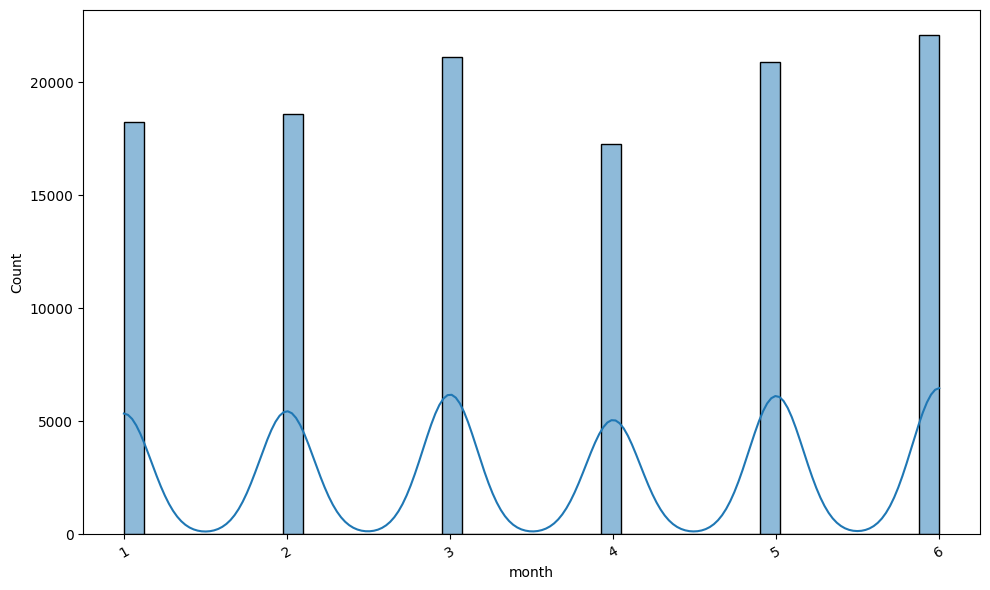

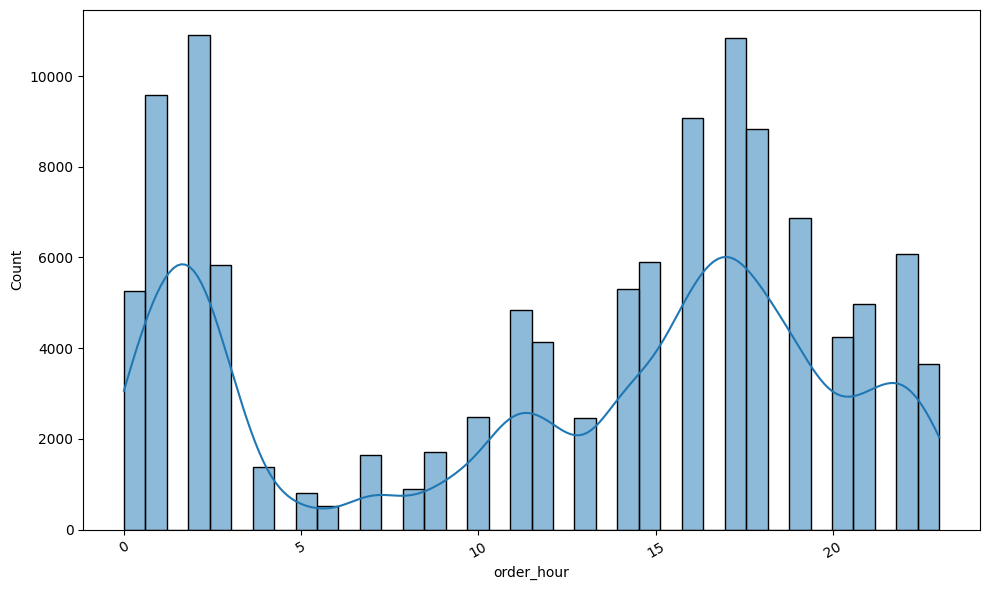

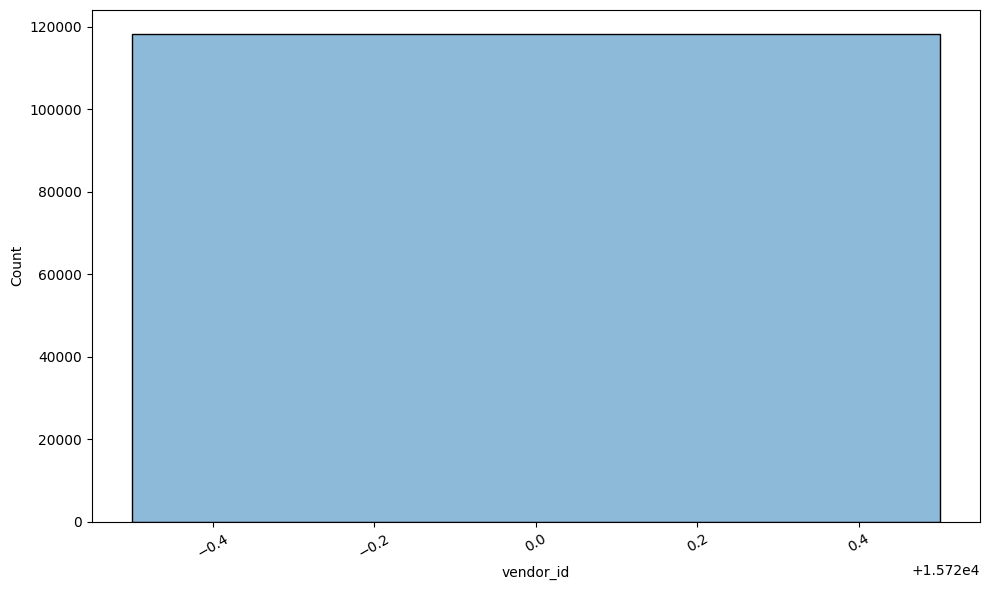

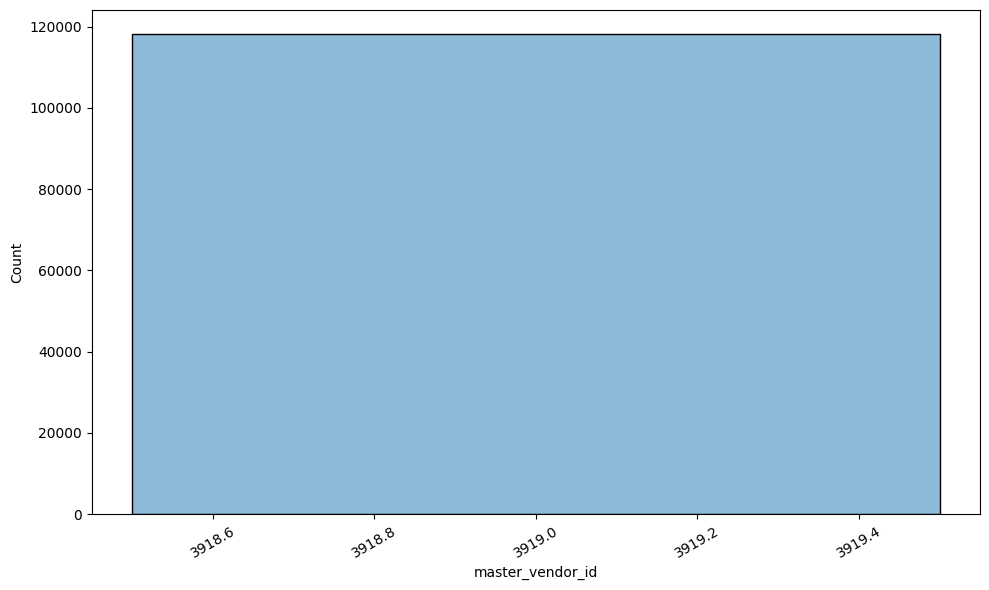

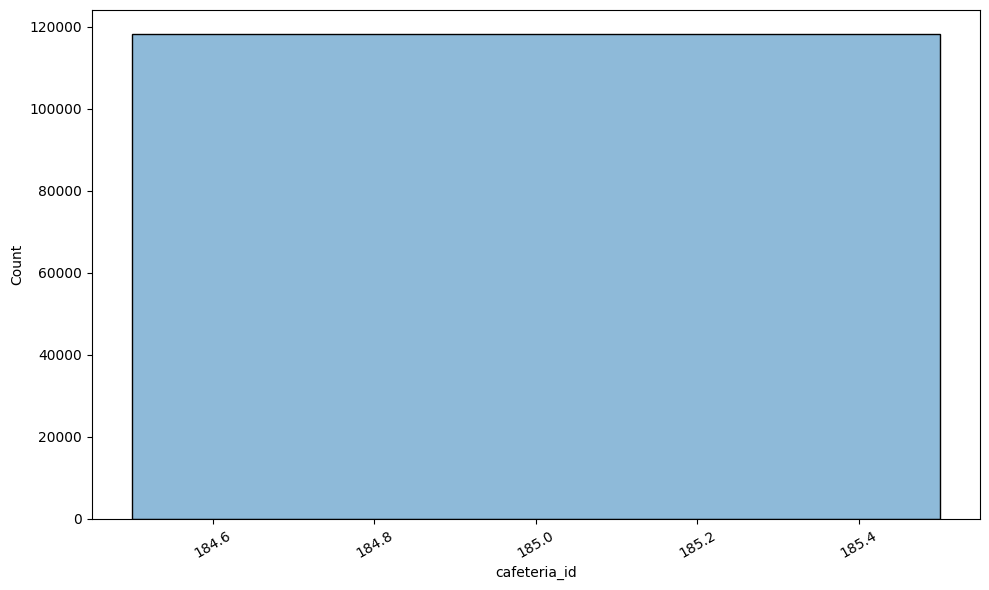

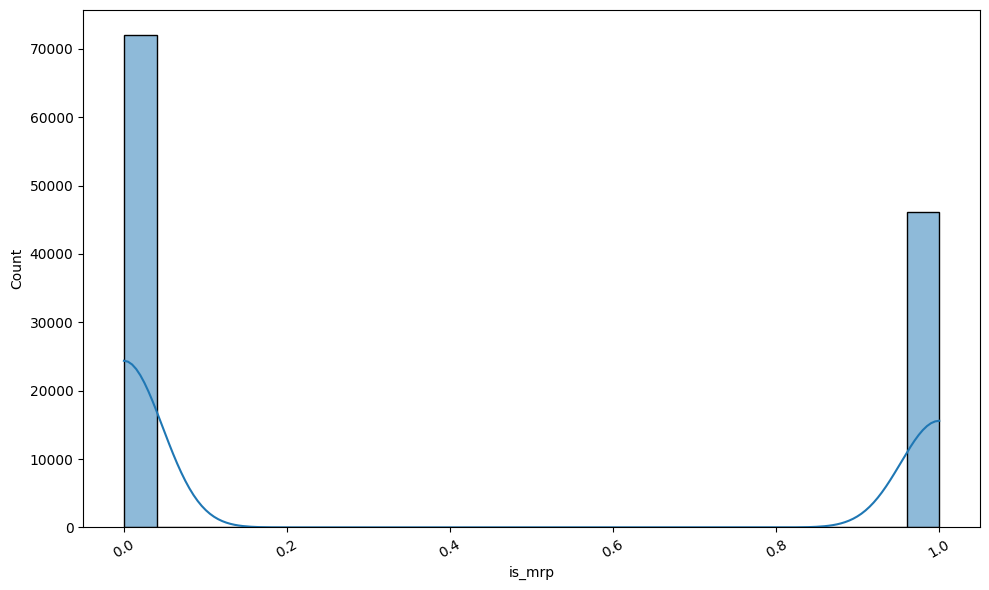

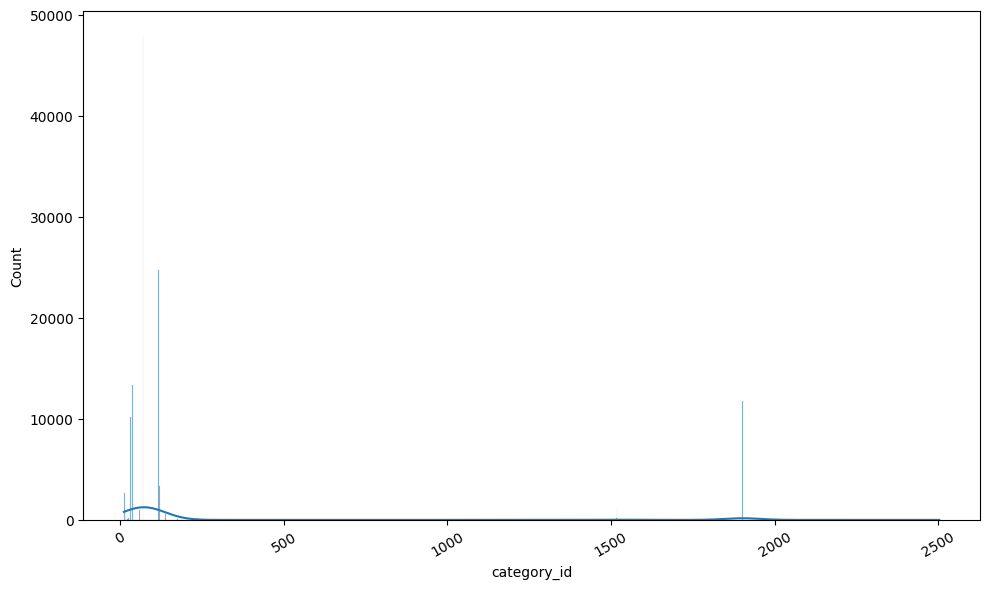

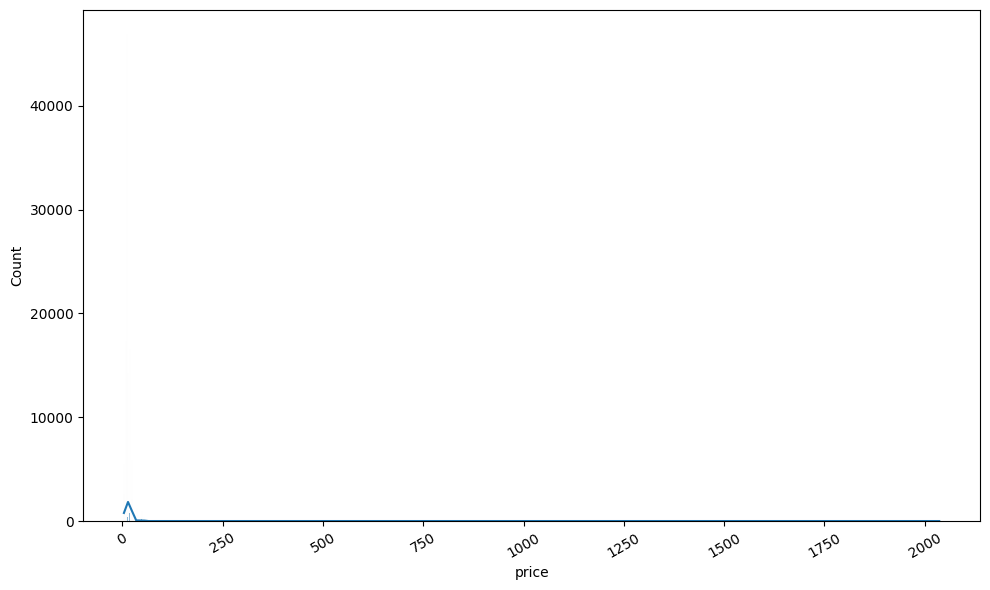

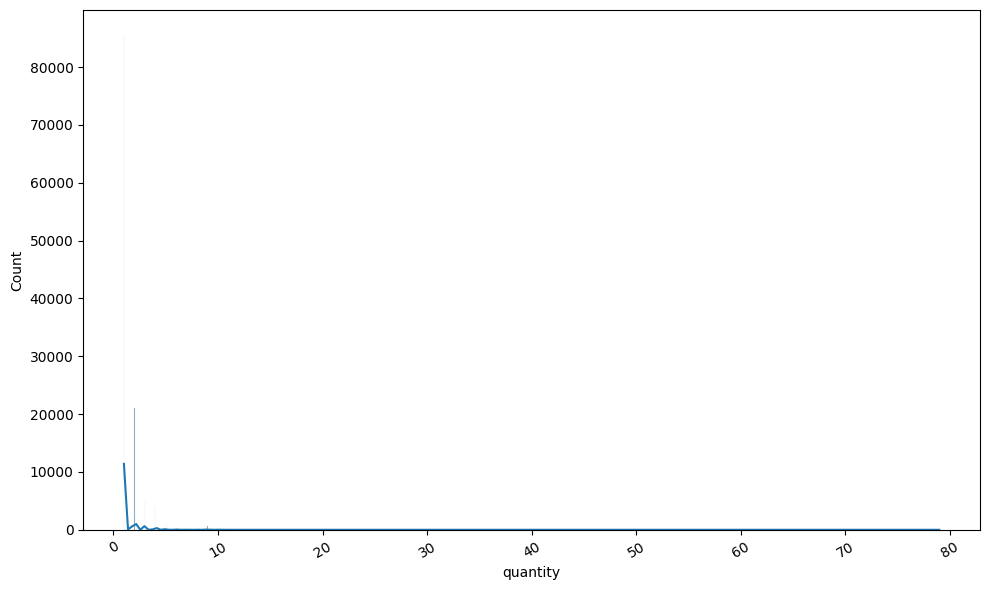

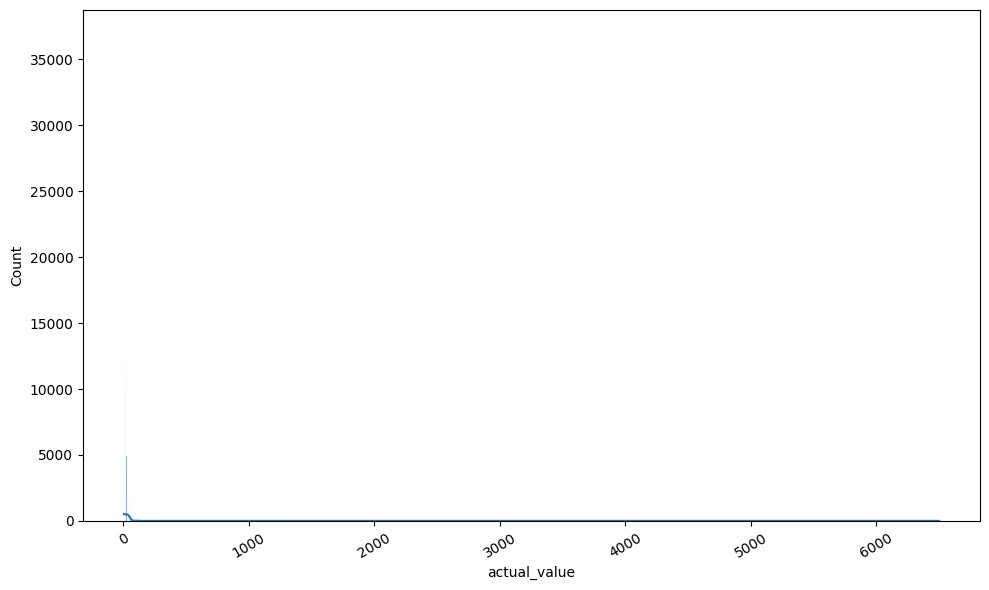

In [ ]:
for i in num_col :
  plt.figure(figsize=(10,6))
  sns.histplot(data=df,x= i,kde=True)
  plt.xticks(rotation=30)
  plt.tight_layout()
  plt.show()


In [ ]:
df.to_csv('Tuck_shop_data.csv',index=False)